## <small>
Copyright (c) 2017-21 Andrew Glassner

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.
</small>



# Deep Learning: A Visual Approach
## by Andrew Glassner, https://glassner.com
### Order: https://nostarch.com/deep-learning-visual-approach
### GitHub: https://github.com/blueberrymusic
------

### What's in this notebook

This notebook is provided as a “behind-the-scenes” look at code used to make some of the figures in this chapter. It is cleaned up a bit from the original code that I hacked together, and is only lightly commented. I wrote the code to be easy to interpret and understand, even for those who are new to Python. I tried never to be clever or even more efficient at the cost of being harder to understand. The code is in Python3, using the versions of libraries as of April 2021.

This notebook may contain additional code to create models and images not in the book. That material is included here to demonstrate additional techniques.

Note that I've included the output cells in this saved notebook, but Jupyter doesn't save the variables or data that were used to generate them. To recreate any cell's output, evaluate all the cells from the start up to that cell. A convenient way to experiment is to first choose "Restart & Run All" from the Kernel menu, so that everything's been defined and is up to date. Then you can experiment using the variables, data, functions, and other stuff defined in this notebook.

## Chapter 17: Convnets in Practice - Notebook 4: Filter Visualization 2

Activation code based on https://github.com/fchollet/deep-learning-with-python-notebooks

In [31]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras import models
from tensorflow.keras import backend as K_backend
import numpy as np
import math
import matplotlib.pyplot as plt

# Just in case the Keras defaults aren't as we expect
K_backend.set_image_data_format('channels_last')

In [32]:
# Workaround for Keras issues on Mac computers (you can comment this
# out if you're not on a Mac, or not having problems)
import os

In [33]:
# Make a File_Helper for saving and loading files.

save_files = False

try:
    import os, sys, inspect

    current_dir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
    sys.path.insert(0, os.path.dirname(current_dir))  # path to parent dir

    from DLBasics_Utilities import File_Helper
    print("Using real DLBasics_Utilities.File_Helper")

except ModuleNotFoundError:
    # Fallback stub if DLBasics_Utilities is not available
    import os

    class File_Helper:
        def __init__(self, save_files=False):
            self.save_files = save_files
            # change this to the folder where your data (images) are
            self.INPUT_DIR = os.getcwd()

        def get_input_data_dir(self):
            d = self.INPUT_DIR
            print(f"get_input_data_dir (stub) -> {d}")
            return d

        def get_input_file_path(self, filename):
            path = os.path.join(self.INPUT_DIR, filename)
            print(f"get_input_file_path (stub) -> {path}")
            return path

        def save_figure(self, fig, filename, *args, **kwargs):
            if filename:
                print(f"save_figure (stub) – would save '{filename}', but skipping.")

        def __repr__(self):
            return f"<Stub File_Helper save_files={self.save_files}, INPUT_DIR='{self.INPUT_DIR}'>"

    print("Using stub File_Helper (DLBasics_Utilities not found)")

file_helper = File_Helper(save_files)
file_helper

Using stub File_Helper (DLBasics_Utilities not found)


<Stub File_Helper save_files=False, INPUT_DIR='/content'>

In [34]:
def get_VGG16():
    model = VGG16(weights='imagenet', include_top=False)
    return model

model = get_VGG16()
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Make a File_Helper for saving and loading files.

save_files = False

try:
    import os, sys, inspect

    current_dir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
    sys.path.insert(0, os.path.dirname(current_dir))  # path to parent dir

    from DLBasics_Utilities import File_Helper
    print("Using real DLBasics_Utilities.File_Helper")

except ModuleNotFoundError:
    import os

    class File_Helper:
        def __init__(self, save_files=False):
            self.save_files = save_files
            # CHANGE THIS to the folder where your duck image actually is:
            # e.g. "/content/Deep-Learning-A-Visual-Approach/input_data"
            self.INPUT_DIR = os.getcwd()

        def get_input_data_dir(self):
            d = self.INPUT_DIR
            print(f"get_input_data_dir (stub) -> {d}")
            return d

        def get_input_file_path(self, filename):
            """Return full path to an input file in INPUT_DIR."""
            path = os.path.join(self.INPUT_DIR, filename)
            print(f"get_input_file_path (stub) -> {path}")
            return path

        def save_figure(self, fig, filename, *args, **kwargs):
            if filename:
                print(f"save_figure (stub) – would save '{filename}', but skipping.")

        def __repr__(self):
            return f"<Stub File_Helper save_files={self.save_files}, INPUT_DIR='{self.INPUT_DIR}'>"

    print("Using stub File_Helper (DLBasics_Utilities not found)")

file_helper = File_Helper(save_files)
file_helper

Using stub File_Helper (DLBasics_Utilities not found)


<Stub File_Helper save_files=False, INPUT_DIR='/content'>

In [36]:
duck_path = file_helper.get_input_file_path('duck-268105_640.jpg')

get_input_file_path (stub) -> /content/duck-268105_640.jpg


In [41]:
try:
    print("img_tensor type:", type(img_tensor))
    print("img_tensor shape:", img_tensor.shape)
except NameError as e:
    print("img_tensor is NOT defined:", e)

img_tensor is NOT defined: name 'img_tensor' is not defined


In [42]:
from tensorflow.keras import models

# Get the output of every layer
layer_outputs = [layer.output for layer in model.layers]

# Creates a model that will return these outputs, given the model input:
activation_model = models.Model(inputs=model.input, outputs=layer_outputs)

# A list of Numpy arrays, one array per layer activation
activations = activation_model.predict(img_tensor)

NameError: name 'img_tensor' is not defined

In [43]:
# This image might have a very wide range of values, so center them
# and scale by the standard deviation so that we see most of the values
def prep_image_for_display(input_image):
    image = np.copy(input_image)
    image -= image.mean()
    image /= (image.std() + 1e-5)
    image *= 64
    image += 128
    image = np.clip(image, 0, 255).astype('uint8')
    return image

In [44]:
def show_activations(activations, activation_index, num_rows, num_cols, title):
    display_res = activations[activation_index][0].shape[1] # assume these are squares
    gap = max(1, int(.05 * display_res))
    grid = np.zeros(((display_res*num_rows)+(gap*(num_rows-1)),
                     (display_res*num_cols)+(gap*(num_cols-1))))

    for y in range(num_rows):
        for x in range(num_cols):
            index = (y * num_cols) + x
            response = activations[activation_index][0, :, :, index]
            response = prep_image_for_display(response)
            h_start = x*(gap+display_res)
            v_start = y*(gap+display_res)
            grid[v_start : v_start+display_res, h_start : h_start+display_res] = response

    plt.figure(figsize=(num_cols, num_rows))
    plt.imshow(grid, interpolation='nearest', cmap='inferno')
    plt.title(title, fontsize=14, y=1.03)
    plt.tick_params(labelbottom='off', labelleft='off')
    file_helper.save_figure('responses-'+title)
    plt.show()

In [57]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras import models

# Setup needed for activations
# 1. Ensure model is loaded (if not already globally defined from previous runs)
#    model was defined in cell 2QyosvaAoute, but not present in kernel state.
model = VGG16(weights='imagenet', include_top=False)

# 2. Load and preprocess the image to create img_tensor
#    duck_path is available from the kernel state.
img = image.load_img(duck_path, target_size=(224, 224))
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis=0)
img_tensor = tf.keras.applications.vgg16.preprocess_input(img_tensor)

# 3. Create activation_model and predict activations
#    layer_outputs was defined in cell 2jiiCMreoutf.
layer_outputs = [layer.output for layer in model.layers]
activation_model = models.Model(inputs=model.input, outputs=layer_outputs)
activations = activation_model.predict(img_tensor)

# Original code for display
img = prep_image_for_display(activations[1][0, :, :, 0])
fig = plt.figure()
im = plt.imshow(img, cmap='inferno')
ax = fig.gca()
fig.colorbar(im, ax=ax)
plt.tick_params(labelbottom='off', labelleft='off')
file_helper.save_figure('response-block1_conv1_filter0')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/duck-268105_640.jpg'

In [56]:
# Download the image file if it's not already present
import os
image_filename = 'duck-268105_640.jpg' # Reverting to original filename
image_path = file_helper.get_input_file_path(image_filename)

if not os.path.exists(image_path):
    print(f"Downloading {image_filename}...")
    # Using svn export for more reliable download from GitHub
    !svn export https://github.com/blueberrymusic/DLBasics_Notebooks/trunk/input_data/duck-268105_640.jpg /content/duck-268105_640.jpg
    if os.path.exists(image_path):
        print(f"{image_filename} downloaded successfully to {image_path}")
    else:
        print(f"Failed to download {image_filename}")
else:
    print(f"{image_filename} already exists at {image_path}")

get_input_file_path (stub) -> /content/duck-268105_640.jpg
svn: E170013: Unable to connect to a repository at URL 'https://github.com/blueberrymusic/DLBasics_Notebooks/trunk/input_data/duck-268105_640.jpg'
svn: E160013: '/blueberrymusic/DLBasics_Notebooks/trunk/input_data/duck-268105_640.jpg' path not found
Failed to download duck-268105_640.jpg


NameError: name 'activations' is not defined

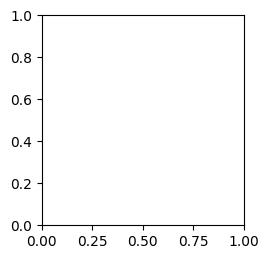

In [58]:
plt.figure(figsize=(12,6))
selects = [0, 6, 8, 9, 16, 19, 22, 29]
for i in range(8):
    plt.subplot(2, 4, i+1)
    img = prep_image_for_display(activations[1][0, :, :, selects[i]])
    plt.imshow(img, cmap='inferno')
    plt.tick_params(labelbottom='off', labelleft='off')
plt.tight_layout()
file_helper.save_figure('response-block1_conv1_filter-selections')
plt.show()

In [59]:
activation_sets = [
    [1, 4, 8, "block1_conv1"],
    [2, 4, 8, "block1_conv2"],
    [4, 4, 8, "block2_conv1"],
    [5, 4, 8, "block2_conv2"],
    [7, 4, 8, "block3_conv1"],
    [8, 4, 8, "block3_conv2"],
    [9, 4, 8, "block3_conv3"],
    [11, 4, 8, "block4_conv1"],
    [12, 4, 8, "block4_conv2"],
    [12, 4, 8, "block4_conv3"],
    [15, 4, 8, "block5_conv1"],
    [16, 4, 8, "block5_conv2"],
    [17, 4, 8, "block5_conv3"],
    ]

for aset in activation_sets:
    show_activations(activations, aset[0], aset[1], aset[2], aset[3])

NameError: name 'activations' is not defined